# Airline NLP Analytics

This notebook uses Tweets.csv and AirlineReviews.csv to perform:
- Sentiment analysis (positive / negative / neutral)
- Aspect-based sentiment analysis: food, delays, staff, seat comfort, baggage, check-in, wi-fi
- Complaint classification
- Emotion detection: frustration, anger, satisfaction, stress
- Feedback history analysis
- Churn signal detection
- Dissatisfied frequent flyers (proxy from tweet user names)
- Loyalty drivers
- Smart recommendation system

## Data sources
- data/Tweets.csv (text + airline_sentiment)
- data/AirlineReviews.csv (Title, Review, OverallScore, Recommended)

Notes:
- Review sentiment labels are derived from OverallScore: <=4 negative, 5-6 neutral, >=7 positive.
- If OverallScore is missing, Recommended=yes/no is used.
- Some tasks use heuristics and keyword rules for transparency.

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import label_binarize

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid", palette="muted")

In [2]:
base_dir = Path.cwd()
if not (base_dir / "data").exists():
    for parent in base_dir.parents:
        if (parent / "data").exists():
            base_dir = parent
            break

data_dir = base_dir / "data"
if not data_dir.exists():
    raise FileNotFoundError(f"data folder not found from {Path.cwd()}")

reviews_path = data_dir / "AirlineReviews.csv"
tweets_path = data_dir / "Tweets.csv"

if not reviews_path.exists():
    raise FileNotFoundError(f"Missing file: {reviews_path}")
if not tweets_path.exists():
    raise FileNotFoundError(f"Missing file: {tweets_path}")

df_reviews = pd.read_csv(
    reviews_path,
    usecols=lambda c: c in {
        "Title", "Review", "OverallScore", "Recommended",
        "DatePub", "DateFlown", "AirlineName", "OriginCountry",
        "TravelType", "TripVerified", "CabinType", "Route",
        "unique_id"
    },
    low_memory=False
)
df_tweets = pd.read_csv(
    tweets_path,
    usecols=lambda c: c in {
        "text", "airline_sentiment", "tweet_created",
        "airline", "name", "tweet_location", "user_timezone"
    },
    low_memory=False
)

print(f"Reviews rows: {len(df_reviews):,}")
print(f"Tweets rows : {len(df_tweets):,}")

Reviews rows: 129,455
Tweets rows : 14,640


In [3]:
def build_review_labels(df):
    text_cols = [c for c in ["Title", "Review"] if c in df.columns]
    if text_cols:
        df["text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1).str.strip()
    else:
        df["text"] = ""

    score = pd.to_numeric(df.get("OverallScore"), errors="coerce")
    df["label"] = pd.cut(score, bins=[-1, 4, 6, 10], labels=["negative", "neutral", "positive"])

    rec = df.get("Recommended")
    if rec is not None:
        rec = rec.astype(str).str.lower()
        df.loc[df["label"].isna(), "label"] = rec.map({"yes": "positive", "no": "negative"})

    df["date"] = pd.to_datetime(df.get("DatePub"), errors="coerce")
    df["source"] = "reviews"
    df["airline"] = df.get("AirlineName")
    df["user_id"] = df.get("unique_id")
    df["travel_type"] = df.get("TravelType")
    return df[["source", "text", "label", "date", "airline", "user_id", "travel_type"]]

df_reviews = build_review_labels(df_reviews)

df_tweets = df_tweets.rename(columns={"airline_sentiment": "label"})
df_tweets["label"] = df_tweets["label"].astype(str).str.lower()
df_tweets = df_tweets[df_tweets["label"].isin(["negative", "neutral", "positive"])]
df_tweets["text"] = df_tweets["text"].astype(str)
df_tweets["date"] = pd.to_datetime(df_tweets.get("tweet_created"), errors="coerce")
df_tweets["source"] = "tweets"
df_tweets["airline"] = df_tweets.get("airline")
df_tweets["user_id"] = df_tweets.get("name")
df_tweets["travel_type"] = None
df_tweets = df_tweets[["source", "text", "label", "date", "airline", "user_id", "travel_type"]]

df_all = pd.concat([df_reviews, df_tweets], ignore_index=True)
df_all["text"] = df_all["text"].fillna("").str.strip()
df_all = df_all[df_all["text"].str.len() > 0].reset_index(drop=True)

print("Label distribution:")
print(df_all["label"].value_counts())

Label distribution:
label
negative    82322
positive    48866
neutral     12907
Name: count, dtype: int64


## 1. Sentiment analysis

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub("http\\S+|www\\S+", " ", text)
    text = re.sub("@\\w+", " ", text)
    text = re.sub("#", " ", text)  # garder le mot du hashtag, retirer seulement le #
    text = re.sub("[^a-z0-9\\s]", " ", text)
    text = re.sub("\\s+", " ", text).strip()
    return text

df_all["text_clean"] = df_all["text"].map(clean_text)

X = df_all["text_clean"]
y = df_all["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=15000, stop_words="english")
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(X_train_vec, y_train)

y_pred = clf.predict(X_test_vec)
proba = clf.predict_proba(X_test_vec)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
y_bin = label_binarize(y_test, classes=clf.classes_)
auc = roc_auc_score(y_bin, proba, average="macro")

print(f"Accuracy={acc:.3f}  F1(w)={f1:.3f}  ROC-AUC={auc:.3f}")
print(classification_report(y_test, y_pred))

X_all_vec = tfidf.transform(X)
df_all["pred_sentiment"] = clf.predict(X_all_vec)
df_all["pred_confidence"] = clf.predict_proba(X_all_vec).max(axis=1)

# === Enhanced sentiment analysis: keyword-based overrides + clause-level support ===

POSITIVE_KEYWORDS = [
    "loyal customer", "loyalty", "love", "loved", "great", "excellent",
    "amazing", "friendly", "wonderful", "fantastic", "awesome", "delighted",
    "outstanding", "superb", "perfect", "best experience", "recommend",
    "thank you", "appreciate", "pleased",
]
NEGATIVE_KEYWORDS = [
    "disappointing", "disappointed", "terrible", "horrible", "awful",
    "worst", "ruined", "unhelpful", "rude", "frustrating", "annoying",
    "useless", "waste of money", "nightmare", "appalling", "ridiculous",
]

def _has_phrase(cleaned, phrase):
    if " " in phrase:
        return phrase in cleaned
    return re.search(r"\b" + re.escape(phrase) + r"\b", cleaned) is not None

def _has_any(cleaned, phrases):
    return any(_has_phrase(cleaned, p) for p in phrases)

def _make_pattern(words):
    words = [re.escape(w) for w in words]
    return r"(?:\b" + "|".join(words) + r"\b)"

# Split text into clauses on punctuation + contrast connectors
_CONTRAST_SPLIT = re.compile(
    r"(?:[\.;!\?\n]+)|(?:,?\s*\b(?:but|however|although|though|yet|whereas|while|despite|even though|on the other hand)\b\s*)",
    flags=re.IGNORECASE,
)

def split_clauses(raw_text):
    parts = _CONTRAST_SPLIT.split(str(raw_text))
    return [p.strip() for p in parts if p and p.strip()]

def detect_churn_in(cleaned):
    if "churn_terms" not in globals():
        return False
    pat = "|".join(re.escape(t) for t in churn_terms)
    return bool(re.search(pat, cleaned))

def predict_sentiment(raw_clause):
    """Returns (sentiment, confidence, cleaned_text, is_churn).
    Applies rule-based overrides (loyalty/churn keywords) on top of TF-IDF model
    so short clauses are classified correctly even with weak signal."""
    cleaned = clean_text(raw_clause)
    if not cleaned:
        return "neutral", 0.0, cleaned, False

    vec = tfidf.transform([cleaned])
    pred = clf.predict(vec)[0]
    conf = float(np.max(clf.predict_proba(vec)[0]))

    is_churn = detect_churn_in(cleaned)
    has_neg_kw = _has_any(cleaned, NEGATIVE_KEYWORDS)
    has_pos_kw = _has_any(cleaned, POSITIVE_KEYWORDS)

    # Priority: churn / negative keywords > positive keywords > model
    if is_churn or has_neg_kw:
        if pred != "negative":
            pred = "negative"
            conf = 0.95 if is_churn else 0.90
    elif has_pos_kw:
        if pred != "positive":
            pred = "positive"
            conf = 0.90

    return pred, conf, cleaned, is_churn

def detect_aspects_in(cleaned):
    """Returns list of aspect names found in the cleaned text."""
    if "aspects" not in globals():
        return []
    found = []
    for name, keywords in aspects.items():
        pattern = _make_pattern(keywords)
        if re.search(pattern, cleaned):
            found.append(name)
    return found

def detect_emotion_in(cleaned):
    """Returns the primary emotion detected in the cleaned text."""
    if "emotion_lex" not in globals():
        return "neutral"
    scores = {}
    for emo, keys in emotion_lex.items():
        scores[emo] = sum(1 for k in keys if k in cleaned)
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else "neutral"

def classify_complaint_in(cleaned):
    """Returns complaint category based on keywords in the cleaned text."""
    if "complaint_rules" not in globals():
        return "other"
    for cat, keys in complaint_rules.items():
        for k in keys:
            if k in cleaned:
                return cat
    return "other"

Accuracy=0.808  F1(w)=0.830  ROC-AUC=0.918
              precision    recall  f1-score   support

    negative       0.94      0.83      0.88     16464
     neutral       0.29      0.58      0.39      2582
    positive       0.90      0.84      0.87      9773

    accuracy                           0.81     28819
   macro avg       0.71      0.75      0.71     28819
weighted avg       0.87      0.81      0.83     28819



### 1.1 Evaluation approfondie du modele

Au-dela de l'accuracy globale, on regarde **ou** le modele se trompe (matrice de confusion), sa **robustesse** (validation croisee sans fuite via pipeline), sa stabilite **par source** (reviews vs tweets = domaines differents) et son **interpretabilite** (termes les plus negatifs).

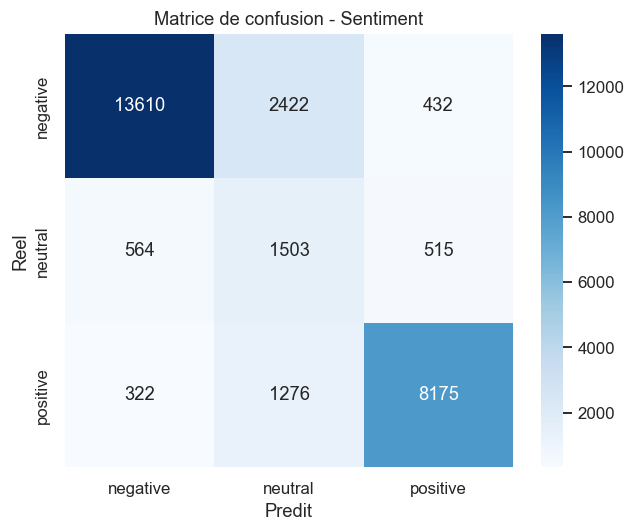

Cross-val F1(weighted) : 0.755 +/- 0.056  (5 folds)

Performance par source :
  reviews  -> Acc=0.825  F1=0.846  (n=25,889)
  tweets   -> Acc=0.660  F1=0.684  (n=2,930)


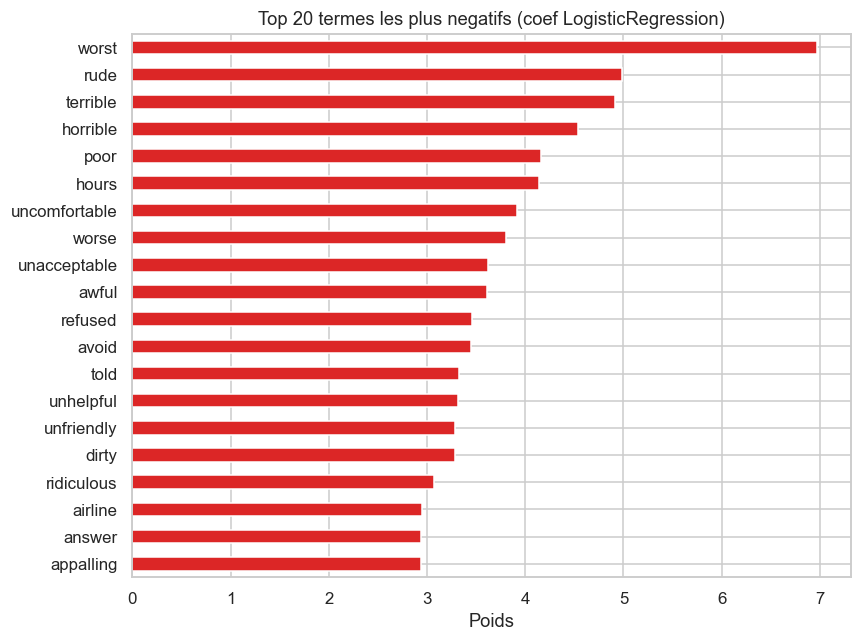

In [5]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# --- Matrice de confusion (test set) ---
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clf.classes_, yticklabels=clf.classes_, ax=ax)
ax.set_xlabel('Predit'); ax.set_ylabel('Reel')
ax.set_title('Matrice de confusion - Sentiment')
plt.tight_layout(); plt.show()

# --- Validation croisee 5 folds (pipeline = TF-IDF refit par fold, pas de fuite) ---
pipe_cv = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=15000, stop_words='english')),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced')),
])
cv_f1 = cross_val_score(pipe_cv, X, y, cv=5, scoring='f1_weighted', n_jobs=-1)
print(f'Cross-val F1(weighted) : {cv_f1.mean():.3f} +/- {cv_f1.std():.3f}  (5 folds)')

# --- Performance par source (domain shift reviews vs tweets) ---
test_src = df_all.loc[X_test.index, 'source'].values
yt = y_test.values
print('\nPerformance par source :')
for src in pd.unique(test_src):
    m = test_src == src
    print(f'  {src:8s} -> Acc={accuracy_score(yt[m], y_pred[m]):.3f}  '
          f'F1={f1_score(yt[m], y_pred[m], average="weighted"):.3f}  (n={m.sum():,})')

# --- Interpretabilite : termes les plus negatifs ---
if 'negative' in list(clf.classes_):
    neg_idx = list(clf.classes_).index('negative')
    top_neg = pd.Series(clf.coef_[neg_idx], index=tfidf.get_feature_names_out()).nlargest(20)
    fig, ax = plt.subplots(figsize=(8, 6))
    top_neg.sort_values().plot(kind='barh', color='#dc2626', ax=ax)
    ax.set_title('Top 20 termes les plus negatifs (coef LogisticRegression)')
    ax.set_xlabel('Poids')
    plt.tight_layout(); plt.show()

### 1.2 Baseline lexicale (VADER)

On compare le modele entraine a **VADER**, un analyseur de sentiment a base de lexique (aucun apprentissage). Si le TF-IDF + LogisticRegression bat VADER, l'apport du ML est demontre ; sinon, c'est une limite a discuter.

In [6]:
# Baseline VADER (lexique, sans apprentissage) appliquee au texte brut du test set
try:
    import nltk
    from nltk.sentiment import SentimentIntensityAnalyzer
    try:
        nltk.data.find('sentiment/vader_lexicon.zip')
    except LookupError:
        nltk.download('vader_lexicon')

    sia = SentimentIntensityAnalyzer()

    def vader_label(text):
        c = sia.polarity_scores(str(text))['compound']
        if c >= 0.05:
            return 'positive'
        if c <= -0.05:
            return 'negative'
        return 'neutral'

    raw_test = df_all.loc[X_test.index, 'text']
    v_pred = raw_test.map(vader_label).values
    print(f'VADER (lexique) -> Acc={accuracy_score(y_test, v_pred):.3f}  '
          f'F1={f1_score(y_test, v_pred, average="weighted"):.3f}')
    print(f'TF-IDF + LogReg -> Acc={accuracy_score(y_test, y_pred):.3f}  '
          f'F1={f1_score(y_test, y_pred, average="weighted"):.3f}')
except Exception as e:
    print('VADER indisponible (pip install nltk) :', e)

VADER (lexique) -> Acc=0.739  F1=0.726
TF-IDF + LogReg -> Acc=0.808  F1=0.830


## 2. Aspect-based sentiment analysis

In [7]:
aspects = {
    "food": ["food", "meal", "snack", "drink", "beverage", "catering"],
    "delays": ["delay", "delayed", "late", "cancel", "cancelled", "canceled", "reschedule", "missed", "waiting", "hold"],
    "staff": ["staff", "crew", "attendant", "service", "agent", "desk", "support", "help"],
    "seat_comfort": ["seat", "legroom", "leg room", "recline", "comfort", "cabin", "space"],
    "baggage": ["baggage", "bag", "luggage", "lost", "claim", "carry-on", "carryon"],
    "check_in": ["check-in", "check in", "boarding", "gate", "security", "tsa", "counter"],
    "wifi": ["wifi", "wi-fi", "internet", "connection", "online"]
}

def make_pattern(words):
    words = [re.escape(w) for w in words]
    return "(?:\\b" + "|".join(words) + "\\b)"

for name, words in aspects.items():
    pattern = make_pattern(words)
    df_all[f"aspect_{name}"] = df_all["text_clean"].str.contains(pattern, regex=True, na=False)

aspect_rows = []
for name in aspects:
    mask = df_all[f"aspect_{name}"]
    if mask.any():
        dist = df_all.loc[mask, "pred_sentiment"].value_counts(normalize=True) * 100
        aspect_rows.append({
            "aspect": name,
            "count": int(mask.sum()),
            "pos_pct": round(dist.get("positive", 0), 1),
            "neu_pct": round(dist.get("neutral", 0), 1),
            "neg_pct": round(dist.get("negative", 0), 1)
        })

aspect_df = pd.DataFrame(aspect_rows).sort_values("count", ascending=False)
aspect_df

,aspect,count,pos_pct,neu_pct,neg_pct
2,staff,103257,38.0,15.9,46.2
3,seat_comfort,71740,44.3,20.7,35.0
1,delays,64173,18.6,11.8,69.6
0,food,58670,49.5,22.4,28.1
5,check_in,48679,32.1,15.2,52.7
4,baggage,38792,24.1,12.2,63.7
6,wifi,18011,28.4,14.9,56.7


## 3. Complaint classification

In [8]:
complaint_rules = {
    "delays_cancellations": ["delay", "delayed", "late", "cancel", "cancelled", "canceled", "missed", "reschedule"],
    "baggage_issues": ["baggage", "bag", "luggage", "lost", "claim", "damaged"],
    "staff_service": ["rude", "staff", "crew", "attendant", "agent", "support", "service", "help"],
    "seat_comfort": ["seat", "legroom", "recline", "comfort", "space"],
    "check_in_boarding": ["check-in", "check in", "boarding", "gate", "counter", "security", "tsa"],
    "food_quality": ["food", "meal", "snack", "drink", "beverage"],
    "wifi_entertainment": ["wifi", "wi-fi", "internet", "entertainment", "tv"],
    "booking_refund": ["booking", "booked", "reservation", "refund", "charge", "fee", "price", "pricing"]
}

def classify_complaint(text):
    for cat, keys in complaint_rules.items():
        for k in keys:
            if k in text:
                return cat
    return "other"

df_all["complaint_category"] = "none"
neg_mask = df_all["pred_sentiment"] == "negative"
df_all.loc[neg_mask, "complaint_category"] = df_all.loc[neg_mask, "text_clean"].apply(classify_complaint)

df_all["complaint_category"].value_counts()

complaint_category
none                    71486
delays_cancellations    41439
staff_service           12690
baggage_issues          10808
other                    3196
seat_comfort             2240
booking_refund            961
check_in_boarding         829
food_quality              315
wifi_entertainment        131
Name: count, dtype: int64

## 4. Emotion detection

In [9]:
emotion_lex = {
    "frustration": ["frustrat", "annoy", "upset", "fed up", "tired of", "irritat"],
    "anger": ["angry", "furious", "mad", "rage", "pissed", "outrage"],
    "satisfaction": ["happy", "pleased", "great", "amazing", "love", "excellent", "awesome", "delight"],
    "stress": ["stress", "anxious", "worried", "panic", "nervous", "pressure"]
}

def detect_emotion(text):
    scores = {}
    for emo, keys in emotion_lex.items():
        scores[emo] = sum(1 for k in keys if k in text)
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else "neutral"

df_all["emotion"] = df_all["text_clean"].apply(detect_emotion)
df_all["emotion"].value_counts()

emotion
neutral         86464
satisfaction    25520
anger           23819
frustration      6033
stress           2259
Name: count, dtype: int64

## 5. Feedback history

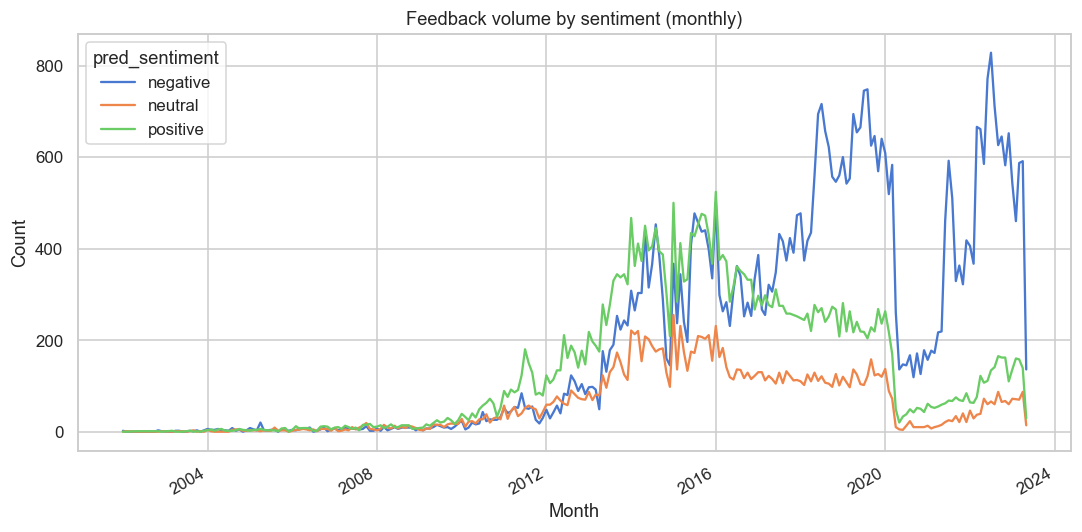

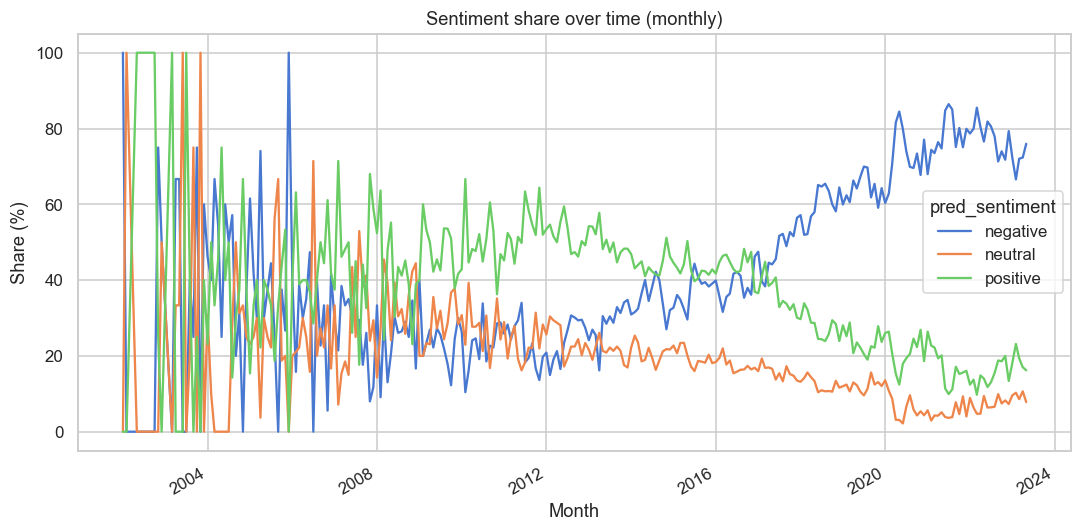

In [10]:
df_hist = df_all.copy()
df_hist["date"] = pd.to_datetime(df_hist["date"], errors="coerce")
df_hist = df_hist.dropna(subset=["date"]).copy()
if df_hist.empty:
    print("No valid dates found for history analysis.")
else:
    df_hist["month"] = df_hist["date"].dt.to_period("M").dt.to_timestamp()
    trend = df_hist.groupby(["month", "pred_sentiment"]).size().unstack(fill_value=0)
    trend.plot(kind="line")
    plt.title("Feedback volume by sentiment (monthly)")
    plt.xlabel("Month")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    trend_pct = trend.div(trend.sum(axis=1), axis=0) * 100
    trend_pct.plot(kind="line")
    plt.title("Sentiment share over time (monthly)")
    plt.xlabel("Month")
    plt.ylabel("Share (%)")
    plt.tight_layout()
    plt.show()

## 6. Churn signal detection

In [11]:
churn_terms = [
    "never fly", "never again", "wont fly", "won't fly", "stop flying",
    "switch", "boycott", "cancel membership", "close account",
    "refund", "chargeback", "take my business", "lost my business"
]
pattern = "|".join([re.escape(t) for t in churn_terms])
df_all["churn_signal"] = df_all["text_clean"].str.contains(pattern, regex=True, na=False)

print(df_all["churn_signal"].value_counts())
df_all.loc[df_all["churn_signal"], ["source", "airline", "pred_sentiment", "text"]].head(5)

churn_signal
False    126001
True      18094
Name: count, dtype: int64


,source,airline,pred_sentiment,text
10,reviews,Adria Airways,negative,I will never fly again with Adria Please do a ...
13,reviews,Adria Airways,negative,worse than the budget airlines Ljubljana to Zü...
24,reviews,Adria Airways,negative,should be ashamed of their operations Ljubljan...
27,reviews,Adria Airways,negative,never fly this airline again Ljubljana to Muni...
33,reviews,Adria Airways,negative,"fleet is tired and outdated ✅ , | Munich to L..."


## 7. Dissatisfied frequent flyers (tweets proxy)

In [12]:
df_t = df_all[(df_all["source"] == "tweets") & df_all["user_id"].notna()].copy()
if df_t.empty:
    print("No tweet user ids available.")
else:
    freq = df_t.groupby("user_id").agg(
        total=("user_id", "size"),
        neg_rate=("pred_sentiment", lambda s: (s == "negative").mean())
    )
    freq = freq[freq["total"] >= 3].sort_values(["neg_rate", "total"], ascending=False)
    freq.head(10)

## 8. Loyalty drivers

In [13]:
if "positive" in clf.classes_:
    pos_idx = list(clf.classes_).index("positive")
    coef = clf.coef_[pos_idx]
    top_pos = pd.Series(coef, index=tfidf.get_feature_names_out()).nlargest(20)
    top_pos
else:
    print("Positive class not found in model classes.")

aspect_pos = []
for name in aspects:
    mask = df_all[f"aspect_{name}"]
    if mask.any():
        pos_rate = (df_all.loc[mask, "pred_sentiment"] == "positive").mean() * 100
        aspect_pos.append({
            "aspect": name,
            "positive_rate_pct": round(pos_rate, 1),
            "count": int(mask.sum())
        })
pd.DataFrame(aspect_pos).sort_values("positive_rate_pct", ascending=False)

,aspect,positive_rate_pct,count
0,food,49.5,58670
3,seat_comfort,44.3,71740
2,staff,38.0,103257
5,check_in,32.1,48679
6,wifi,28.4,18011
4,baggage,24.1,38792
1,delays,18.6,64173


## 9. Smart recommendation system

In [14]:
def recommend_actions(row):
    actions = []
    if row["pred_sentiment"] == "negative":
        if row.get("aspect_delays"):
            actions.append("Offer delay compensation and proactive rebooking")
        if row.get("aspect_baggage"):
            actions.append("Provide baggage tracking and priority handling")
        if row.get("aspect_staff"):
            actions.append("Service recovery follow-up and staff coaching")
        if row.get("aspect_check_in"):
            actions.append("Streamline check-in and boarding support")
        if row.get("aspect_wifi"):
            actions.append("Wi-Fi credit or connectivity fix")
        if row.get("aspect_food"):
            actions.append("Meal or voucher compensation")
        if row.get("aspect_seat_comfort"):
            actions.append("Seat comfort fix or seat upgrade credit")
    else:
        actions.append("Invite to loyalty program or add bonus points")
        if row.get("aspect_seat_comfort"):
            actions.append("Suggest premium seat upgrade")
        if row.get("aspect_wifi"):
            actions.append("Offer premium Wi-Fi package")

    if row.get("churn_signal"):
        actions.append("Priority retention outreach")

    travel = str(row.get("travel_type") or "").lower()
    if "business" in travel:
        actions.append("Offer lounge access and flexible ticket options")

    if not actions:
        actions.append("General service follow-up")
    return actions

sample = df_all.sample(5, random_state=42).copy()
sample["recommendations"] = sample.apply(recommend_actions, axis=1)
sample["text_short"] = sample["text"].str.slice(0, 120)
sample[["source", "airline", "pred_sentiment", "emotion", "complaint_category", "churn_signal", "text_short", "recommendations"]]

,source,airline,pred_sentiment,emotion,complaint_category,churn_signal,text_short,recommendations
111717,reviews,TAP Portugal,neutral,neutral,none,False,"the plane was very clean ✅ , | Flying TP929 f...",[Invite to loyalty program or add bonus points...
17980,reviews,AirAsia,negative,anger,delays_cancellations,False,"had about 30 minutes to run ✅ , | Flew AirAsi...",[Offer delay compensation and proactive rebook...
120634,reviews,United Airlines,negative,anger,delays_cancellations,False,recent experience was absolutely horrible I fl...,[Offer delay compensation and proactive rebook...
117049,reviews,VietJet Air,negative,frustration,delays_cancellations,False,VietJet is always delayed Taipei to Ho Chi Min...,[Offer delay compensation and proactive rebook...
17818,reviews,Alaska Airlines,negative,neutral,staff_service,False,we still haven't left the gate Seattle to Tamp...,[Service recovery follow-up and staff coaching...


In [15]:
# --- Test one text input (with mixed-sentiment / aspect-level breakdown) ---
from IPython.display import HTML, display
import html as _html

# === Configuration ===
# Multi-line input supported: paste an email / message between the triple quotes.
# Line breaks, blank lines and signatures are all preserved.
test_text = """
Amazing. Another 4-hour delay. Exactly what I needed today
""".strip()
test_user_id = None
test_airline = None
test_date = None
test_travel_type = None

if not test_text or not str(test_text).strip():
    raise ValueError("test_text is empty. Paste a message and rerun.")
if "clf" not in globals() or "tfidf" not in globals():
    raise ValueError("Run the sentiment analysis cell before testing.")
if "aspects" not in globals():
    raise ValueError("Aspects not found. Run the aspect-based cell first.")

# === Analysis (uses pre-defined functions from training cells) ===

overall_pred, overall_conf, full_clean, full_churn = predict_sentiment(test_text)
overall_aspects = detect_aspects_in(full_clean)
overall_emotion = detect_emotion_in(full_clean)
overall_complaint = classify_complaint_in(full_clean) if overall_pred == "negative" else "none"

clauses = split_clauses(test_text)
clause_rows = []
aspect_sentiment = {}

for cl in clauses:
    sent, conf, cleaned, is_churn = predict_sentiment(cl)
    asp = detect_aspects_in(cleaned)
    clause_rows.append({
        "clause": cl,
        "sentiment": sent,
        "confidence": conf,
        "aspects": asp,
        "churn": is_churn,
    })
    for a in asp:
        aspect_sentiment.setdefault(a, {"positive": [], "negative": [], "neutral": []})
        aspect_sentiment[a][sent].append(cl)

churn_signal = full_churn or any(r["churn"] for r in clause_rows)
clause_sents = {r["sentiment"] for r in clause_rows}
is_mixed = ("positive" in clause_sents) and ("negative" in clause_sents)
overall_verdict = "mixed" if is_mixed else overall_pred

aspect_verdict = {}
for a, buckets in aspect_sentiment.items():
    has_pos, has_neg = bool(buckets["positive"]), bool(buckets["negative"])
    if has_pos and has_neg:
        aspect_verdict[a] = "mixed"
    elif has_pos:
        aspect_verdict[a] = "positive"
    elif has_neg:
        aspect_verdict[a] = "negative"
    else:
        aspect_verdict[a] = "neutral"

row = {"pred_sentiment": overall_pred, "churn_signal": churn_signal, "travel_type": test_travel_type}
for name in aspects:
    row[f"aspect_{name}"] = aspect_verdict.get(name) in ("negative", "mixed")

effective_sentiment_for_reco = "negative" if any(v in ("negative", "mixed") for v in aspect_verdict.values()) else overall_pred
row["pred_sentiment"] = effective_sentiment_for_reco
recommendations = recommend_actions(row) if "recommend_actions" in globals() else []

# === Display ===

ASPECT_LABELS = {
    "food": "Food & beverage", "delays": "Delays / cancellations", "staff": "Staff & crew",
    "seat_comfort": "Seat comfort", "baggage": "Baggage", "check_in": "Check-in / boarding", "wifi": "Wi-Fi",
}
SENT_COLORS = {
    "positive": ("#16a34a", "#dcfce7", "[+]"),
    "negative": ("#dc2626", "#fee2e2", "[-]"),
    "neutral":  ("#6b7280", "#f3f4f6", "[ ]"),
    "mixed":    ("#d97706", "#fef3c7", "[~]"),
}

def _pill(text, color, bg):
    return f'<span style="background:{bg};color:{color};padding:2px 10px;border-radius:999px;font-size:12px;font-weight:600;border:1px solid {color}22;">{_html.escape(text)}</span>'

def _aspect_card(aspect_key, verdict, quotes_by_sent):
    color, bg, icon = SENT_COLORS[verdict]
    label = ASPECT_LABELS.get(aspect_key, aspect_key)
    quote_html = "".join(
        f'<div style="margin-top:6px;padding:6px 10px;background:{_bg};border-left:3px solid {_c};border-radius:4px;font-size:13px;color:#111;"><span style="color:{_c};font-weight:700;margin-right:6px;">{_i}</span><i>"{_html.escape(q)}"</i></div>'
        for s in ("positive", "negative", "neutral") for q in quotes_by_sent.get(s, [])
        for (_c, _bg, _i) in [SENT_COLORS[s]]
    )
    return f'<div style="border:1px solid #e5e7eb;border-radius:10px;padding:12px 14px;margin:8px 0;background:#fff;"><div style="display:flex;align-items:center;justify-content:space-between;"><div style="font-weight:700;font-size:14px;color:#111;">{icon} {_html.escape(label)}</div>{_pill(verdict.upper(), color, bg)}</div>{quote_html}</div>'

sent_color, sent_bg = SENT_COLORS[overall_verdict][:2]
mixed_banner = f'<div style="margin-top:10px;padding:10px 14px;background:{SENT_COLORS["mixed"][1]};border-left:4px solid {SENT_COLORS["mixed"][0]};border-radius:6px;color:#111;font-size:13px;"><b>[~] Mixed sentiment detected.</b> Different parts express opposite feelings - see the per-aspect breakdown below.</div>' if is_mixed else ""

aspect_cards_html = "".join(_aspect_card(a, aspect_verdict[a], aspect_sentiment[a]) for a in aspect_sentiment) or '<div style="padding:10px;color:#6b7280;font-size:13px;">No specific aspect mentioned.</div>'

def _clause_row(r):
    churn_badge = '<span style="background:#fee2e2;color:#dc2626;padding:1px 8px;border-radius:999px;font-size:11px;font-weight:700;margin-left:6px;border:1px solid #dc262633;">CHURN</span>' if r["churn"] else ''
    aspects_str = ", ".join(ASPECT_LABELS.get(a, a) for a in r["aspects"]) or "-"
    return f'<tr><td style="padding:6px 10px;border-bottom:1px solid #f1f5f9;font-size:13px;"><i>"{_html.escape(r["clause"])}"</i> {churn_badge}</td><td style="padding:6px 10px;border-bottom:1px solid #f1f5f9;white-space:nowrap;">{_pill(r["sentiment"], *SENT_COLORS[r["sentiment"]][:2])}<span style="color:#6b7280;font-size:12px;margin-left:6px;">{r["confidence"]*100:.0f}%</span></td><td style="padding:6px 10px;border-bottom:1px solid #f1f5f9;font-size:12px;color:#374151;">{aspects_str}</td></tr>'

clause_table = "".join(_clause_row(r) for r in clause_rows)

reco_html = "".join(f'<li style="margin:4px 0;font-size:13px;color:#111;">{_html.escape(a)}</li>' for a in recommendations) or '<li style="color:#6b7280;font-size:13px;">No specific action needed.</li>'

meta_pills = " ".join([
    _pill(f"emotion: {overall_emotion}", "#7c3aed", "#ede9fe"),
    _pill(f"complaint: {overall_complaint}", "#0891b2", "#cffafe"),
    _pill("CHURN RISK" if churn_signal else "no churn signal", "#dc2626" if churn_signal else "#6b7280", "#fee2e2" if churn_signal else "#f3f4f6"),
])

html_out = f"""<div style="font-family:Segoe UI,Roboto,system-ui,Arial,sans-serif;max-width:880px;border:1px solid #e5e7eb;border-radius:14px;padding:20px;background:#fafafa;"><div style="font-size:12px;color:#6b7280;letter-spacing:.08em;text-transform:uppercase;">NLP analysis</div><div style="margin-top:6px;font-size:16px;color:#111;line-height:1.45;"><b>Input:</b><pre style="white-space:pre-wrap;margin:6px 0 0;font-family:inherit;font-style:italic;">{_html.escape(test_text)}</pre></div><div style="margin-top:14px;display:flex;align-items:center;gap:10px;flex-wrap:wrap;"><div style="font-size:13px;color:#374151;">Overall sentiment</div>{_pill(overall_verdict.upper(), sent_color, sent_bg)}<span style="color:#6b7280;font-size:12px;">model confidence {overall_conf*100:.0f}%</span></div>{mixed_banner}<div style="margin-top:18px;font-weight:700;color:#111;">Aspect breakdown</div>{aspect_cards_html}<div style="margin-top:18px;font-weight:700;color:#111;">Clause-by-clause</div><table style="width:100%;border-collapse:collapse;background:#fff;border:1px solid #e5e7eb;border-radius:8px;overflow:hidden;margin-top:6px;"><thead><tr style="background:#f9fafb;text-align:left;"><th style="padding:8px 10px;font-size:12px;color:#374151;">Clause</th><th style="padding:8px 10px;font-size:12px;color:#374151;">Sentiment</th><th style="padding:8px 10px;font-size:12px;color:#374151;">Aspects</th></tr></thead><tbody>{clause_table}</tbody></table><div style="margin-top:18px;display:flex;gap:8px;flex-wrap:wrap;">{meta_pills}</div><div style="margin-top:18px;font-weight:700;color:#111;">Recommended actions</div><ul style="margin:6px 0 0 18px;padding:0;">{reco_html}</ul></div>"""

display(HTML(html_out))

result = {
    "input": test_text,
    "overall_sentiment": overall_verdict,
    "model_sentiment": overall_pred,
    "confidence": round(overall_conf, 3),
    "is_mixed": is_mixed,
    "aspect_verdict": aspect_verdict,
    "clauses": clause_rows,
    "emotion": overall_emotion,
    "complaint_category": overall_complaint,
    "churn_signal": churn_signal,
    "recommendations": recommendations,
}
result

Clause,Sentiment,Aspects
"""Amazing""",positive99%,-
"""Another 4-hour delay""",negative87%,Delays / cancellations
"""Exactly what I needed today""",neutral76%,-


{'input': 'Amazing. Another 4-hour delay. Exactly what I needed today',
 'overall_sentiment': 'mixed',
 'model_sentiment': 'positive',
 'confidence': 0.514,
 'is_mixed': True,
 'aspect_verdict': {'delays': 'negative'},
 'clauses': [{'clause': 'Amazing',
   'sentiment': 'positive',
   'confidence': 0.9926542302225102,
   'aspects': [],
   'churn': False},
  {'clause': 'Another 4-hour delay',
   'sentiment': 'negative',
   'confidence': 0.8675349357389981,
   'aspects': ['delays'],
   'churn': False},
  {'clause': 'Exactly what I needed today',
   'sentiment': 'neutral',
   'confidence': 0.7648163181463343,
   'aspects': [],
   'churn': False}],
 'emotion': 'satisfaction',
 'complaint_category': 'none',
 'churn_signal': False,
 'recommendations': ['Offer delay compensation and proactive rebooking']}

## 10. Validation des modules a base de regles

Les modules **aspects / reclamations** reposent sur des regles par mots-cles. On les valide sur un petit jeu annote manuellement pour donner une precision indicative au lieu de "faire confiance" aux regles.

In [16]:
# Mini jeu annote a la main (verite terrain) pour les modules a base de regles
eval_samples = [
    {'text': 'The food was cold and the meal service was terrible',
     'aspects': {'food'},        'complaint': 'food_quality'},
    {'text': 'Flight delayed 3 hours and I missed my connection',
     'aspects': {'delays'},      'complaint': 'delays_cancellations'},
    {'text': 'The crew was rude and unhelpful at the desk',
     'aspects': {'staff'},       'complaint': 'staff_service'},
    {'text': 'They lost my luggage and nobody helped with the claim',
     'aspects': {'baggage'},     'complaint': 'baggage_issues'},
    {'text': 'The seat had no legroom and was very uncomfortable',
     'aspects': {'seat_comfort'},'complaint': 'seat_comfort'},
    {'text': 'The wifi did not work during the entire flight',
     'aspects': {'wifi'},        'complaint': 'wifi_entertainment'},
    {'text': 'Check-in and boarding at the gate were chaotic',
     'aspects': {'check_in'},    'complaint': 'check_in_boarding'},
    {'text': 'I want a refund for my booking, I was overcharged',
     'aspects': set(),           'complaint': 'booking_refund'},
]

asp_ok = comp_ok = 0
for s in eval_samples:
    cleaned = clean_text(s['text'])
    pred_asp = set(detect_aspects_in(cleaned))
    pred_comp = classify_complaint_in(cleaned)
    asp_hit = s['aspects'].issubset(pred_asp)   # tous les aspects attendus detectes
    comp_hit = pred_comp == s['complaint']
    asp_ok += asp_hit; comp_ok += comp_hit
    print(f"[{'OK' if asp_hit else 'KO'}] aspects={pred_asp or '{}'}"
          f"   [{'OK' if comp_hit else 'KO'}] complaint={pred_comp}")

n = len(eval_samples)
print(f'\nAspects     : {asp_ok}/{n} corrects ({asp_ok / n * 100:.0f}%)')
print(f'Reclamations: {comp_ok}/{n} corrects ({comp_ok / n * 100:.0f}%)')

[OK] aspects={'staff', 'food'}   [KO] complaint=staff_service
[OK] aspects={'delays', 'wifi'}   [OK] complaint=delays_cancellations
[OK] aspects={'staff'}   [OK] complaint=staff_service
[OK] aspects={'baggage'}   [OK] complaint=baggage_issues
[OK] aspects={'seat_comfort'}   [OK] complaint=seat_comfort
[OK] aspects={'wifi'}   [OK] complaint=wifi_entertainment
[OK] aspects={'check_in'}   [OK] complaint=check_in_boarding
[OK] aspects={}   [OK] complaint=booking_refund

Aspects     : 8/8 corrects (100%)
Reclamations: 7/8 corrects (88%)


## 11. Export des predictions vers le Data Warehouse

On materialise les sorties NLP (sentiment, reclamation, emotion, churn, aspects) dans un CSV pret a etre charge dans le STAGING/DWH. C'est le pont entre la couche ML et le modele en etoile du projet.

In [17]:
# Export des predictions enrichies pour integration au Data Warehouse
export_cols = ['source', 'airline', 'user_id', 'date', 'text',
               'pred_sentiment', 'pred_confidence', 'complaint_category',
               'emotion', 'churn_signal']
export_cols += [c for c in df_all.columns if c.startswith('aspect_')]
export_cols = [c for c in export_cols if c in df_all.columns]

nlp_export = df_all[export_cols].copy()
out_path = (data_dir / 'nlp_predictions.csv') if 'data_dir' in globals() else Path('nlp_predictions.csv')
nlp_export.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'Exporte {len(nlp_export):,} lignes -> {out_path}')
nlp_export.head()

Exporte 144,095 lignes -> c:\Users\RaedCHARRAD\Desktop\esprit\3eme\Mission entreprise 2\Airline_Datawarehouse\data\nlp_predictions.csv


,source,airline,user_id,date,text,pred_sentiment,pred_confidence,complaint_category,emotion,churn_signal,aspect_food,aspect_delays,aspect_staff,aspect_seat_comfort,aspect_baggage,aspect_check_in,aspect_wifi
0,reviews,AB Aviation,d3b260fb-268b-4399-8a9b-2804825902c6,2019-11-11 00:00:00,pretty decent airline Moroni to Moheli. Turned...,positive,0.847806,none,neutral,False,False,False,False,False,False,True,True
1,reviews,AB Aviation,307711df-268f-4698-97b8-45729b7d972e,2019-06-25 00:00:00,Not a good airline Moroni to Anjouan. It is a ...,negative,0.591034,delays_cancellations,neutral,False,False,True,False,False,False,True,False
2,reviews,AB Aviation,82bd2602-171d-4724-bde0-90b71621cdcf,2019-06-25 00:00:00,flight was fortunately short Anjouan to Dzaoud...,neutral,0.536481,none,neutral,False,False,False,True,True,False,True,False
3,reviews,Aerocaribbean,a927beb4-6244-4f5c-9dc3-09890aa3e616,NaT,Aerocaribbean customer review Havana - Cayo Co...,positive,0.695036,none,neutral,False,True,False,False,True,False,False,False
4,reviews,Aerocaribbean,d7bea425-c58a-4a7e-8269-02e0e6516633,2010-11-25 00:00:00,Aerocaribbean customer review Holguin to Havan...,negative,0.688974,delays_cancellations,neutral,False,False,True,False,False,False,True,False
